In [4]:
from google.colab import files
files.upload()  # upload your kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"animishagadde65","key":"6020241ec743cc336346ded80b500bb4"}'}

In [5]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

!kaggle competitions download -c criteo-display-ad-challenge
!unzip -q criteo-display-ad-challenge.zip
!ls

100% 47.6M/47.6M [00:00<00:00, 85.0MB/s]

criteo-display-ad-challenge.zip  random_submission.zip	sample_data


In [14]:
!kaggle datasets download -d mrkmakr/criteo-dataset
!ls

Dataset URL: https://www.kaggle.com/datasets/mrkmakr/criteo-dataset
License(s): unknown
100% 4.31G/4.31G [01:01<00:00, 74.9MB/s]

criteo-dataset.zip		 random_submission.zip
criteo-display-ad-challenge.zip  sample_data


In [15]:
!kaggle datasets download -d arashnic/ctr-in-advertisement
!unzip -q ctr-in-advertisement.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/arashnic/ctr-in-advertisement
License(s): CC0-1.0
100% 7.14M/7.14M [00:00<00:00, 120MB/s]

 Ad_Click_prediciton_test.csv	      ctr-in-advertisement.zip
'Ad_click_prediction_train (1).csv'   random_submission.zip
 criteo-dataset.zip		      sample_data
 criteo-display-ad-challenge.zip


In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv('Ad_click_prediction_train (1).csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(463291, 15)
['session_id', 'DateTime', 'user_id', 'product', 'campaign_id', 'webpage_id', 'product_category_1', 'product_category_2', 'user_group_id', 'gender', 'age_level', 'user_depth', 'city_development_index', 'var_1', 'is_click']


,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,140690,2017-07-02 00:00,858557,C,359520,13787,4,NaN,10.0,Female,4.0,3.0,3.0,0,0
1,333291,2017-07-02 00:00,243253,C,105960,11085,5,NaN,8.0,Female,2.0,2.0,NaN,0,0
2,129781,2017-07-02 00:00,243253,C,359520,13787,4,NaN,8.0,Female,2.0,2.0,NaN,0,0
3,464848,2017-07-02 00:00,1097446,I,359520,13787,3,NaN,3.0,Male,3.0,3.0,2.0,1,0
4,90569,2017-07-02 00:01,663656,C,405490,60305,3,NaN,2.0,Male,2.0,3.0,2.0,1,0


In [18]:
print(df['is_click'].value_counts())
print(df.isnull().sum())

is_click
0    431960
1     31331
Name: count, dtype: int64
session_id                     0
DateTime                       0
user_id                        0
product                        0
campaign_id                    0
webpage_id                     0
product_category_1             0
product_category_2        365854
user_group_id              18243
gender                     18243
age_level                  18243
user_depth                 18243
city_development_index    125129
var_1                          0
is_click                       0
dtype: int64


In [19]:
from sklearn.preprocessing import LabelEncoder

# Drop unusable columns
df = df.drop(columns=['session_id', 'DateTime', 'user_id', 'product_category_2'])

# Fill missing values
df['user_group_id'] = df['user_group_id'].fillna(-1)
df['gender'] = df['gender'].fillna('Unknown')
df['age_level'] = df['age_level'].fillna(df['age_level'].median())
df['user_depth'] = df['user_depth'].fillna(df['user_depth'].median())
df['city_development_index'] = df['city_development_index'].fillna(df['city_development_index'].median())

# Encode categoricals
cat_cols = ['product', 'campaign_id', 'webpage_id', 'gender']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(df.isnull().sum())
print(df.shape)
df.head()

product                   0
campaign_id               0
webpage_id                0
product_category_1        0
user_group_id             0
gender                    0
age_level                 0
user_depth                0
city_development_index    0
var_1                     0
is_click                  0
dtype: int64
(463291, 11)


,product,campaign_id,webpage_id,product_category_1,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,2,2,1,4,10.0,0,4.0,3.0,3.0,0,0
1,2,0,0,5,8.0,0,2.0,2.0,2.0,0,0
2,2,2,1,4,8.0,0,2.0,2.0,2.0,0,0
3,8,2,1,3,3.0,1,3.0,3.0,2.0,1,0
4,2,6,7,3,2.0,1,2.0,3.0,2.0,1,0


In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_click'])
y = df['is_click']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Click rate: {y.mean():.4f}")

Training set: (370632, 10)
Test set: (92659, 10)
Click rate: 0.0676


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:,1]

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_probs):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
Accuracy:  0.5502
ROC-AUC:   0.5573
F1 Score:  0.1401
              precision    recall  f1-score   support

           0       0.94      0.55      0.70     86393
           1       0.08      0.54      0.14      6266

    accuracy                           0.55     92659
   macro avg       0.51      0.55      0.42     92659
weighted avg       0.88      0.55      0.66     92659



In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),  # handles imbalance
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:,1]

print("=== XGBoost ===")
print(f"Accuracy:  {accuracy_score(y_test, xgb_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"F1 Score:  {f1_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds))

=== XGBoost ===
Accuracy:  0.5964
ROC-AUC:   0.5836
F1 Score:  0.1468
              precision    recall  f1-score   support

           0       0.94      0.60      0.74     86393
           1       0.09      0.51      0.15      6266

    accuracy                           0.60     92659
   macro avg       0.52      0.56      0.44     92659
weighted avg       0.89      0.60      0.70     92659



In [23]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

# Add interaction features
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

X_train_eng['age_depth'] = X_train['age_level'] * X_train['user_depth']
X_test_eng['age_depth'] = X_test['age_level'] * X_test['user_depth']

X_train_eng['city_var'] = X_train['city_development_index'] * X_train['var_1']
X_test_eng['city_var'] = X_test['city_development_index'] * X_test['var_1']

# Apply SMOTE to balance classes
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_eng, y_train)

print(f"After SMOTE - Class distribution:")
print(pd.Series(y_train_res).value_counts())

After SMOTE - Class distribution:
is_click
0    345567
1    345567
Name: count, dtype: int64


In [24]:
# Scale
scaler2 = StandardScaler()
X_train_res_scaled = scaler2.fit_transform(X_train_res)
X_test_eng_scaled = scaler2.transform(X_test_eng)

# Logistic Regression
lr2 = LogisticRegression(random_state=42, max_iter=1000)
lr2.fit(X_train_res_scaled, y_train_res)
lr2_preds = lr2.predict(X_test_eng_scaled)
lr2_probs = lr2.predict_proba(X_test_eng_scaled)[:,1]

print("=== Logistic Regression (with SMOTE) ===")
print(f"Accuracy:  {accuracy_score(y_test, lr2_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr2_probs):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr2_preds):.4f}")

# XGBoost
xgb2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb2.fit(X_train_res, y_train_res)
xgb2_preds = xgb2.predict(X_test_eng)
xgb2_probs = xgb2.predict_proba(X_test_eng)[:,1]

print("\n=== XGBoost (with SMOTE) ===")
print(f"Accuracy:  {accuracy_score(y_test, xgb2_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb2_probs):.4f}")
print(f"F1 Score:  {f1_score(y_test, xgb2_preds):.4f}")
print(classification_report(y_test, xgb2_preds))

=== Logistic Regression (with SMOTE) ===
Accuracy:  0.5553
ROC-AUC:   0.5571
F1 Score:  0.1399

=== XGBoost (with SMOTE) ===
Accuracy:  0.6349
ROC-AUC:   0.5762
F1 Score:  0.1461
              precision    recall  f1-score   support

           0       0.94      0.65      0.77     86393
           1       0.09      0.46      0.15      6266

    accuracy                           0.63     92659
   macro avg       0.51      0.55      0.46     92659
weighted avg       0.89      0.63      0.73     92659



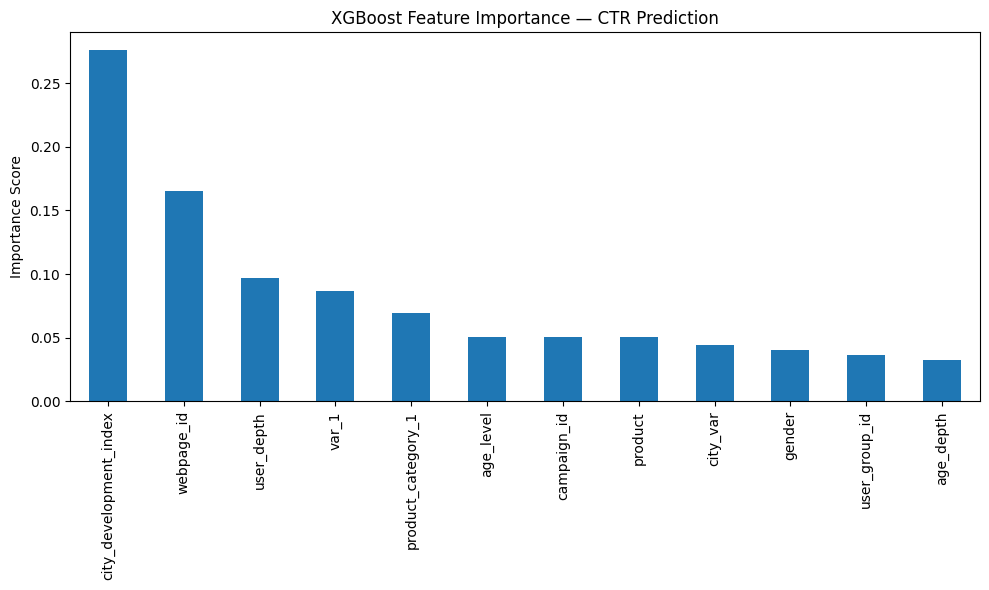

In [25]:
import matplotlib.pyplot as plt

feat_importance = pd.Series(
    xgb2.feature_importances_,
    index=X_train_eng.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importance.plot(kind='bar')
plt.title('XGBoost Feature Importance — CTR Prediction')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [26]:
import pickle
import os

os.makedirs('models', exist_ok=True)

# Save both models
with open('models/lr_ctr_model.pkl', 'wb') as f:
    pickle.dump(lr2, f)

with open('models/xgb_ctr_model.pkl', 'wb') as f:
    pickle.dump(xgb2, f)

# Save scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler2, f)

print("Models saved.")

Models saved.


In [27]:
from google.colab import files
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>